# Task 3: Country-Wise Netflix Content Analysis
**Objective:** Analyze Netflix content availability across countries

## Step 1: Extract and clean country information
Loaded the cleaned dataset, checked the country column, and separated titles with an unknown country so they don't distort rankings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/netflix_cleaned.csv", parse_dates=["date_added"])

#quick check of the country column
print("Total titles:", len(df))
print("Unique country values:", df["country"].nunique())
print("Contains commas (multi-country)?", df["country"].str.contains(",").any())

#separate known and unknown countries
unknown = (df["country"] == "Unknown").sum()
df_country = df[df["country"] != "Unknown"].copy()

print(f"\nUnknown country: {unknown} titles ({unknown/len(df):.1%})")
print("Titles with a known country:", len(df_country))
print("Countries analysed:", df_country["country"].nunique())

Total titles: 8786
Unique country values: 86
Contains commas (multi-country)? False

Unknown country: 287 titles (3.3%)
Titles with a known country: 8499
Countries analysed: 85


## Step 2: Calculate content count by country
Used `groupby` to count titles per country, with each country's share of all titles that have a known country, and the Movie vs TV Show split

In [2]:
#total titles per country
country_counts = (df_country.groupby("country")
                  .size()
                  .sort_values(ascending=False)
                  .rename("total_titles"))

#share of all known-country titles
country_summary = country_counts.to_frame()
country_summary["share_%"] = (country_summary["total_titles"] / len(df_country) * 100).round(1)

#Movie vs TV Show counts per country
type_split = df_country.groupby(["country", "type"]).size().unstack(fill_value=0)
country_summary = country_summary.join(type_split)

country_summary.head(10)

,total_titles,share_%,Movie,TV Show
country,,,,
United States,3240,38.1,2395,845
India,1056,12.4,975,81
United Kingdom,638,7.5,387,251
Pakistan,420,4.9,71,349
Canada,271,3.2,187,84
Japan,259,3.0,87,172
South Korea,214,2.5,49,165
France,213,2.5,148,65
Spain,182,2.1,129,53


## Step 3: Identify top content-producing countries
Ranked the top 10 countries, measured how concentrated the catalogue is, and calculated each country's TV Show share to compare content styles

In [3]:
top10 = country_summary.head(10).copy()

#cumulative share
top10["cumulative_%"] = (top10["total_titles"].cumsum() / len(df_country) * 100).round(1)

#what % of each country's catalogue is TV Shows
top10["tv_show_%"] = (top10["TV Show"] / top10["total_titles"] * 100).round(1)

#rank starting from 1
top10.insert(0, "rank", range(1, 11))
display(top10)

print(f"Top 3 countries:  {top10['cumulative_%'].iloc[2]}% of all titles")
print(f"Top 5 countries:  {top10['cumulative_%'].iloc[4]}% of all titles")
print(f"Top 10 countries: {top10['cumulative_%'].iloc[9]}% of all titles")

,rank,total_titles,share_%,Movie,TV Show,cumulative_%,tv_show_%
country,,,,,,,
United States,1,3240,38.1,2395,845,38.1,26.1
India,2,1056,12.4,975,81,50.5,7.7
United Kingdom,3,638,7.5,387,251,58.1,39.3
Pakistan,4,420,4.9,71,349,63.0,83.1
Canada,5,271,3.2,187,84,66.2,31.0
Japan,6,259,3.0,87,172,69.2,66.4
South Korea,7,214,2.5,49,165,71.7,77.1
France,8,213,2.5,148,65,74.3,30.5
Spain,9,182,2.1,129,53,76.4,29.1


Top 3 countries:  58.1% of all titles
Top 5 countries:  66.2% of all titles
Top 10 countries: 78.0% of all titles


## Step 4: Charts and rankings
- **Chart 1:** Top 10 countries by number of titles, split into Movies and TV Shows
- **Chart 2:** TV Show share per country, compared with the overall average

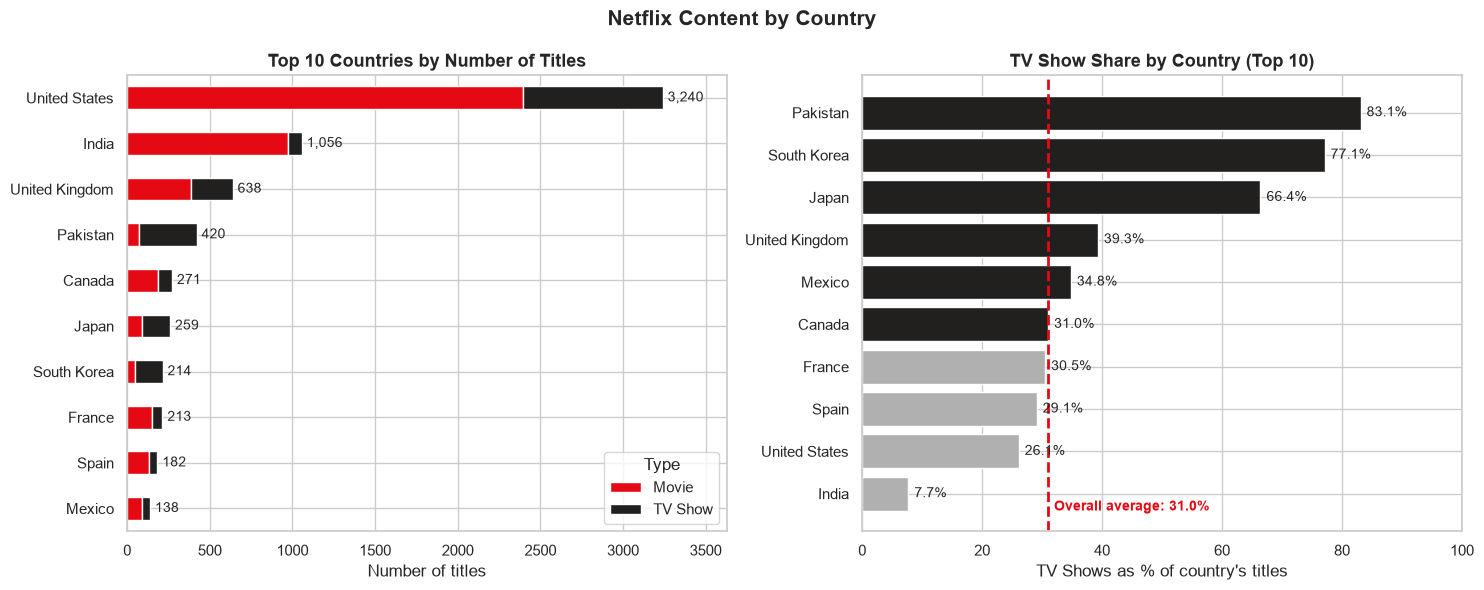

In [4]:
sns.set_theme(style="whitegrid")
red, black = "#E50914", "#221F1F"

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Chart 1: stacked bar of Movies + TV Shows
ax = axes[0]
plot1 = top10[["Movie", "TV Show"]]
plot1.plot(kind="barh", stacked=True, color=[red, black], edgecolor="white", ax=ax)
ax.invert_yaxis()                      # rank 1 at the top
ax.set_title("Top 10 Countries by Number of Titles", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of titles")
ax.set_ylabel("")
for i, total in enumerate(top10["total_titles"]):
    ax.text(total + 30, i, f"{total:,}", va="center", fontsize=10)
ax.set_xlim(0, top10["total_titles"].max() * 1.12)
ax.legend(title="Type", loc="lower right")

#Chart 2: TV Show share vs overall average
ax = axes[1]
overall_tv = (df_country["type"] == "TV Show").mean() * 100
sorted_tv = top10.sort_values("tv_show_%", ascending=False)
bar_colors = [black if v > overall_tv else "#B0B0B0" for v in sorted_tv["tv_show_%"]]
ax.barh(sorted_tv.index, sorted_tv["tv_show_%"], color=bar_colors)
ax.axvline(overall_tv, color=red, linestyle="--", linewidth=2)
ax.text(overall_tv + 1, 9.4, f"Overall average: {overall_tv:.1f}%", color=red, fontsize=10, fontweight="bold")
ax.invert_yaxis()
ax.set_title("TV Show Share by Country (Top 10)", fontsize=13, fontweight="bold")
ax.set_xlabel("TV Shows as % of country's titles")
ax.set_ylabel("")
for i, v in enumerate(sorted_tv["tv_show_%"]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=10)
ax.set_xlim(0, 100)

plt.suptitle("Netflix Content by Country", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../screenshots/task3_country_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: Business insights

### Where the content comes from
- **38.1%** of titles with a known country come from the **United States**; **India (12.4%)** and the **United Kingdom (7.5%)** follow.
- The **top 3 countries make up 58.1%** of the catalogue and the **top 10 make up 78.0%**, so content supply is highly concentrated.
- 85 countries appear in total, so the remaining 75 countries share only about 22% of titles.

### Content style differs sharply by country
| Country | TV Show share | Pattern |
|---|---|---|
| Pakistan | 83.1% | Series-led |
| South Korea | 77.1% | Series-led |
| Japan | 66.4% | Series-led |
| United Kingdom | 39.3% | Mixed, above average |
| United States | 26.1% | Movie-led, but largest volume of both |
| India | 7.7% | Almost entirely films |

The overall average is **31.0%** TV Shows.

### Business interpretation
- **Concentration risk and opportunity:** reliance on a few countries means a change in US or Indian supply would affect the catalogue heavily. Growing content from mid-sized producers (Canada, France, Spain, Mexico) could diversify it.
- **India is a series gap:** it is the second-largest source of titles, but only 7.7% are TV Shows. Given that series tend to encourage repeat viewing, this may be an opportunity to commission more Indian series.
- **Asian markets lead on series:** Pakistan, South Korea and Japan are strongly series-led, which suggests a strong supply of local-language series.

### Limitations
- Each title has **one country recorded**, so co-productions are credited to a single country.
- 287 titles (3.3%) have an unknown country and were excluded from rankings.
- Counts show catalogue supply, not viewership or revenue.